In [34]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import LabelEncoder

In [21]:
# 데이터 불러오기
df = pd.read_csv('../data/포테이토.csv', encoding='cp949')
df_grow = pd.read_csv('../data/factor_external_weekly_ver_0721.csv', encoding='utf-8')

In [22]:
# year, week 파생
def format_week_int(weekno):
    year = weekno // 100
    week = weekno % 100
    return year, week

df_grow[['year', 'week']] = df_grow['weekno'].apply(lambda x: pd.Series(format_week_int(x)))
df_grow.drop(columns='weekno', inplace=True)

# 병합 전 품목코드 추가
df['item_code'] = 501

# 외생변수 병합
df = pd.merge(
    df,
    df_grow[['year', 'week', 'item_code', 'holiday_flag', 'holiday_score', 'grow_score']],
    on=['year', 'week', 'item_code'],
    how='left'
)

# 병합 후 외생변수 컬럼 재정의
for col in ['holiday_flag', 'holiday_score', 'grow_score']:
    if f"{col}_y" in df.columns:
        df[col] = df[f"{col}_y"]
        df.drop(columns=[f"{col}_x", f"{col}_y"], inplace=True)
df.drop(columns='item_code', inplace=True)

In [23]:
# 불필요 컬럼 제거
# df = df.drop(columns=['등급코드', '일평균기온', '최고기온', '최저기온', '평균상대습도', '강수량(mm)', '1시간최고강수량(mm)'], errors='ignore')

In [24]:
# y, X 분리
y = df['평균단가(원)']
X = df.drop(columns=['평균단가(원)'])

In [37]:
cat_cols = ['직팜산지코드', '품종코드']

for col in cat_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col])

In [ ]:
# 이동평균 및 EMA 파생 변수 생성
# SMA : 단순히 평균한 것
# EMA : 지수이동평균, 최근 데이터에 더 많은 가중치를 부여

def generate_moving_averages(df, target_col='평균단가(원)', group_cols=['직팜산지코드', '품종코드'], windows=[4, 13, 26]):
    df = df.sort_values(group_cols + ['year', 'week']).copy()
    for w in windows:
        df[f'SMA_{w}'] = df.groupby(group_cols)[target_col].transform(lambda x: x.rolling(window=w, min_periods=1).mean())
        df[f'EMA_{w}'] = df.groupby(group_cols)[target_col].transform(lambda x: x.ewm(span=w, adjust=False).mean())
    df['EMA4_SMA4_diff'] = df['EMA_4'] - df['SMA_4']
    df['EMA13_SMA13_diff'] = df['EMA_13'] - df['SMA_13']
    df['EMA26_SMA26_diff'] = df['EMA_26'] - df['SMA_26']
    df['EMA_4_rate'] = df.groupby(group_cols)['EMA_4'].transform(lambda x: x.pct_change().fillna(0))
    df['EMA_13_rate'] = df.groupby(group_cols)['EMA_13'].transform(lambda x: x.pct_change().fillna(0))
    df['EMA_26_rate'] = df.groupby(group_cols)['EMA_26'].transform(lambda x: x.pct_change().fillna(0))
    return df

df = generate_moving_averages(df)

In [27]:
moving_avg_cols = [
    'SMA_4', 'SMA_13', 'SMA_26',
    'EMA_4', 'EMA_13', 'EMA_26',
    'EMA4_SMA4_diff', 'EMA13_SMA13_diff', 'EMA26_SMA26_diff',
    'EMA_4_rate', 'EMA_13_rate', 'EMA_26_rate'
]

df = df.dropna(subset=moving_avg_cols).copy()

# 이동평균 변수 스케일링
scaler = RobustScaler()
X_scaled = scaler.fit_transform(df[moving_avg_cols])
df_scaled = pd.DataFrame(X_scaled, columns=moving_avg_cols, index=df.index)
df.update(df_scaled)

In [28]:
# 모델 학습용 재분리 및 주기형 변수 처리
y = df['평균단가(원)']
X = df.drop(columns=['평균단가(원)'])

# ✅ 여기서 제거하는 게 베스트!
X = X.drop(columns=[
    '등급코드', '일평균기온', '최고기온', '최저기온',
    '평균상대습도', '강수량(mm)', '1시간최고강수량(mm)'
], errors='ignore')

X['week_start'] = pd.to_datetime(X['week_start'])
X['year'] = X['week_start'].dt.year
X['week'] = X['week_start'].dt.isocalendar().week.astype(int)

X['week_sin'] = np.sin(2 * np.pi * X['week'] / 52)
X['week_cos'] = np.cos(2 * np.pi * X['week'] / 52)
X = X.drop(columns=['week'])


In [29]:
X_train = X[X['year'] < 2025].drop(columns=['week_start'])
y_train = y[X['year'] < 2025]
X_test = X[X['year'] == 2025].drop(columns=['week_start'])
y_test = y[X['year'] == 2025]


In [31]:
df.info()
X_train.head()

<class 'pandas.core.frame.DataFrame'>
Index: 160013 entries, 18 to 159687
Data columns (total 47 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   year              160013 non-null  int64  
 1   week              160013 non-null  int64  
 2   week_start        160013 non-null  object 
 3   품종코드              160013 non-null  int64  
 4   등급코드              160013 non-null  int64  
 5   직팜산지코드            160013 non-null  int64  
 6   총거래량(kg)          160013 non-null  float64
 7   일평균기온             160013 non-null  float64
 8   최고기온              160013 non-null  float64
 9   최저기온              160013 non-null  float64
 10  평균상대습도            160013 non-null  float64
 11  강수량(mm)           160013 non-null  float64
 12  1시간최고강수량(mm)      160013 non-null  float64
 13  평균단가(원)           160013 non-null  float64
 14  일평균기온_t-1         160013 non-null  float64
 15  최고기온_t-1          160013 non-null  float64
 16  최저기온_t-1          160013

,year,품종코드,직팜산지코드,총거래량(kg),일평균기온_t-1,최고기온_t-1,최저기온_t-1,평균상대습도_t-1,강수량(mm)_t-1,1시간최고강수량(mm)_t-1,...,SMA_26,EMA_26,EMA4_SMA4_diff,EMA13_SMA13_diff,EMA26_SMA26_diff,EMA_4_rate,EMA_13_rate,EMA_26_rate,week_sin,week_cos
18,2018,1,1000,0.517716,-0.719388,-0.756052,-0.666134,-1.008784,2.079262,-0.137072,...,6.720437,6.793741,0.039378,-0.066365,-0.105873,0.084356,0.063710,0.077607,1.000000,-1.608123e-16
37,2018,1,1000,0.522044,-0.720877,-0.752328,-0.672524,-0.876241,0.390879,-0.137072,...,4.278937,6.425971,1.783488,8.956325,9.206712,-0.455416,-0.575003,-0.582732,1.000000,-1.608123e-16
59,2018,1,1000,-0.404816,-0.867958,-1.052142,-0.635783,-1.093113,-0.184582,-0.137072,...,2.804106,5.936091,0.032284,12.027619,13.653151,-0.605921,-0.809662,-0.838148,1.000000,-1.608123e-16
190,2018,1,1000,0.688749,-0.520420,-0.541899,-0.474441,-0.832645,0.700326,-0.137072,...,4.132889,6.104973,2.882810,7.353556,8.447058,1.111606,0.534310,0.411599,0.992709,-1.205367e-01
211,2018,1,1000,-1.266836,-0.529172,-0.553073,-0.519169,-0.664018,0.385451,-0.137072,...,3.842771,5.851855,3.278808,6.722424,8.631423,-0.224384,-0.367990,-0.413172,0.992709,-1.205367e-01


In [32]:
param_distributions = {
    'n_estimators': [300, 500],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 3],
    'max_features': ['sqrt'],  # 고정
}

In [35]:
# RandomizedSearchCV 설정
search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_distributions,
    n_iter=5,       # 줄임
    cv=2,           # 줄임
    verbose=1,
    n_jobs=-1
)

search.fit(X_train, y_train)
model = search.best_estimator_
pred = model.predict(X_test)

# ✅ 성능 지표 계산
rmse = np.sqrt(mean_squared_error(y_test, pred))
mae = mean_absolute_error(y_test, pred)
mape = mean_absolute_percentage_error(y_test, pred) * 100  # %

r2 = r2_score(y_test, pred)

# ✅ 출력
print("\n🏁 모델 성능:")
print(f"📉 RMSE: {rmse:.2f}")
print(f"📊 MAE : {mae:.2f}")
print(f"📊 MAPE: {mape:.2f}%")
print(f"📈 R²   : {r2:.4f}")

Fitting 2 folds for each of 5 candidates, totalling 10 fits

🏁 모델 성능:
📉 RMSE: 30.81
📊 MAE : 14.03
📊 MAPE: 1.16%
📈 R²   : 0.9984


In [ ]:
# ✅ 성능 지표 계산
rmse = np.sqrt(mean_squared_error(y_test, pred))
mae = mean_absolute_error(y_test, pred)
mape = mean_absolute_percentage_error(y_test, pred) * 100  # %

r2 = r2_score(y_test, pred)

# ✅ 출력
print("\n🏁 모델 성능:")
print(f"📉 RMSE: {rmse:.2f}")
print(f"📊 MAE : {mae:.2f}")
print(f"📊 MAPE: {mape:.2f}%")
print(f"📈 R²   : {r2:.4f}")

In [38]:
# 중요도 추출
importances = model.feature_importances_
feature_names = X_train.columns

# Series로 보기 좋게
import pandas as pd
feat_importance = pd.Series(importances, index=feature_names).sort_values(ascending=False)

# 출력
print("\n🔍 변수 중요도 Top 10")
print(feat_importance.head(10))


🔍 변수 중요도 Top 10
EMA_4             0.177486
EMA_13_rate       0.168267
EMA_26_rate       0.150452
EMA_4_rate        0.144459
SMA_4             0.098115
EMA_13            0.069643
SMA_13            0.054783
EMA_26            0.039944
SMA_26            0.027961
EMA4_SMA4_diff    0.024859
dtype: float64


In [40]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

C:\Users\Admin\AppData\Local\Temp\ipykernel_3400\3283107566.py:7: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.tight_layout()
c:\Users\Admin\anaconda3\envs\ten\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


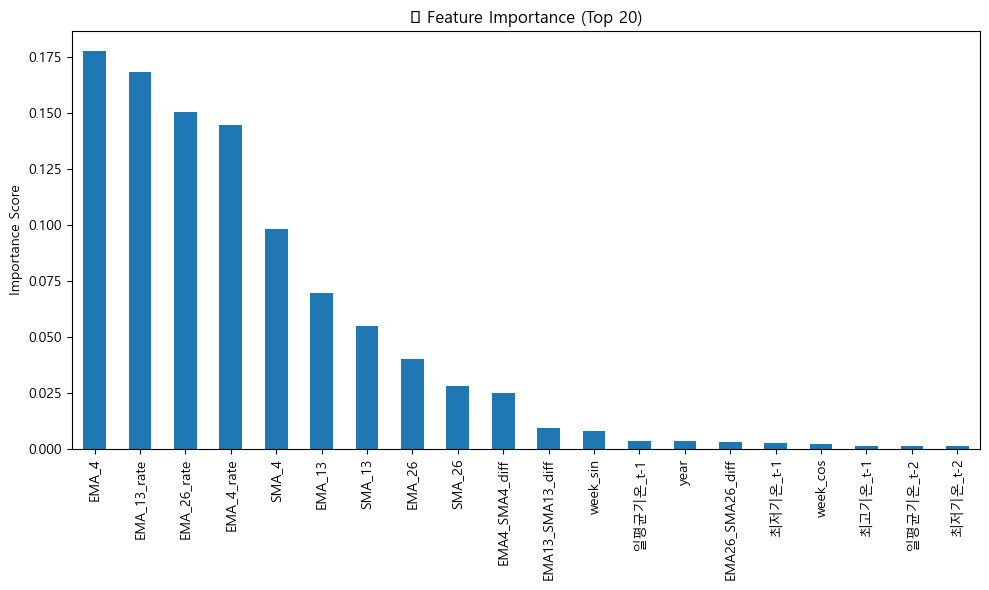

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
feat_importance.head(20).plot(kind='bar')
plt.title('📊 Feature Importance (Top 20)')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show()
